# Avance Fase 3 — Semana 2
## Núcleo algorítmico y Programación Orientada a Objetos aplicado a Airbnb Santiago

**Curso:** MCDI500 — Programación para la Ciencia de Datos · **Programa:** Magíster en Ciencia de Datos e IA, UNAB  
**Proyecto Grupo 3:** Análisis reproducible de precios de alojamientos Airbnb en Santiago

---

> **Propósito del notebook**  
> Aplicación de Programación Orientada a Objetos y Eficiencia Computacional al Análisis de Airbnb
El propósito de este notebook es aplicar conceptos de programación orientada a objetos, preprocesamiento, recursividad y eficiencia computacional sobre el conjunto de datos de Airbnb Santiago, manteniendo la continuidad con las fases anteriores del proyecto y preparando los datos para el análisis de la pregunta del informe: **¿Qué características observables de los alojamientos (ubicación, anfitrión, comuna, etc.) se relacionan con las diferencias de precio?**



## Contenido


1. Los 5 conceptos que necesitas (en 1 minuto)
2. Tu primera clase: `Preprocesador`
3. Ejecucion del Pipeline y Conservacion de la base de   analisis
4. Herencia: reutilizar y especializar
5. Recursividad (idea simple)
6. Eficiencia: ¿por qué evitar bucles?
7. Cómo aplicar esto a **tu** proyecto
8. Bibliografía


## 1. Los conceptos que realizamos

| Concepto | Qué es | En nuestro ejemplo |
|---|---|---|
| **Clase** | El molde o plantilla. | `class Preprocesador:` |
| **Objeto** | Algo creado a partir de la clase. | `prep = Preprocesador("datos.csv")` |
| **Atributo** | Un dato que vive dentro del objeto. | `self.df` (la tabla) |
| **Método** | Una acción del objeto (una función dentro de la clase). | `prep.limpiar()` |
| **`self`** | La palabra que usa el objeto para referirse **a sí mismo**. | `self.df = ...` |

Y un método especial: **`__init__`** es el **constructor**: se ejecuta automáticamente cuando creas el
objeto y sirve para dejar listos sus atributos iniciales.


## 2. Arquitectura de Preprocesamiento y Transformación (POO)

En esta etapa se organiza el flujo de procesamiento mediante Programación Orientada a Objetos (POO), integrando los módulos desarrollados en la carpeta `src/`. 

En lugar de una estructura monolítica, se utiliza una arquitectura modular basada en:
* **Contrato Base (`Transformador`):** Clase abstracta que encapsula los métodos `ajustar()` y `transformar()`.
* **Subclases Especializadas:** Clases como `CodificadorNominal`, `ImputadorMediana` y `EscaladorFlexible` que heredan de la clase base y redefinen el comportamiento.
* **Orquestador (`Pipeline`):** Bucle polimórfico que ejecuta secuencialmente los transformadores.
* **Patrón de Diseño Strategy:** Permite intercambiar dinámicamente entre estrategias de estandarización (`EstrategiaStandard` y `EstrategiaRobust`).

Como archivo de entrada se utiliza la base depurada de la Fase 2 almacenada en la carpeta de datos, manteniendo las variables categóricas y numéricas necesarias para el análisis.


In [1]:
import sys
import os

# Configurar ruta relativa para que el notebook (en F3/notebooks/) reconozca la carpeta src/
sys.path.append(os.path.abspath(os.path.join('..', '..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Carga de módulos POO del proyecto desde src/
from src.limpieza import LimpiadorAirbnb, preparar_filas
from src.transformacion import (
    Pipeline,
    CodificadorNominal,
    EscaladorFlexible,
    ImputadorMediana,
    EstrategiaStandard,
    EstrategiaRobust
)

%matplotlib inline
np.random.seed(42)

# Definir ruta relativa local al archivo de datos de la Fase 2
RUTA_DATOS = os.path.join('..', '..', 'data', 'raw', 'listings.csv.gz')

# Variable central para la pregunta de investigación
PRECIO = "precio_por_noche"

print("✓ Módulos POO cargados y rutas configuradas correctamente.")

✓ Módulos POO cargados y rutas configuradas correctamente.


La clase siguiente mantiene los datos en `self.df`. Cada método cumple una función concreta. Además, guardamos una copia de los datos categóricos en `self.df_analisis` antes del One-Hot Encoding, porque **comuna, tipo de propiedad y tipo de habitación deben seguir siendo legibles para responder la pregunta del informe**.


## 3. Ejecución del Pipeline POO y Conservación de la Base de Análisis

En esta sección se ejecuta la canalización de datos utilizando los módulos desarrollados en la carpeta `src/`.

In [2]:
# 1. CARGA DEL ARCHIVO COMPRIMIDO listings.csv.gz

RUTA_DATOS = os.path.join('..', '..', 'data', 'raw', 'listings.csv.gz')

if not os.path.exists(RUTA_DATOS):
    raise FileNotFoundError(f"No se encontró el archivo en: {RUTA_DATOS}")

df_raw = pd.read_csv(RUTA_DATOS)
print(f"✓ Datos cargados exitosamente: {df_raw.shape[0]:,} filas y {df_raw.shape[1]} columnas.")


# 2. APLICAR LIMPIEZA
# Paso A: Seleccionar variables de la Fase 2 y descartar filas sin precio
df_seleccion, informe_limpieza = preparar_filas(df_raw)
print(f"✓ Filas recibidas: {informe_limpieza['filas_recibidas']:,} | Utiles: {informe_limpieza['filas_utilizables']:,}")

# Paso B: Imputar nulos usando .ajustar_transformar
limpiador = LimpiadorAirbnb()
df_limpio = limpiador.ajustar_transformar(df_seleccion)

# Guardar copia interpretable para análisis descriptivo
df_analisis = df_limpio.copy()
print("✓ Base limpia y copia interpretable creada en 'df_analisis'.")


# 3. DEFINICIÓN Y EJECUCIÓN DE PIPELINE POO DE TRANSFORMACIÓN
pasos_pipeline = [
    # Codificación de variables categóricas
    CodificadorNominal(columna='property_type', prefijo='propiedad'),
    CodificadorNominal(columna='neighbourhood_cleansed', prefijo='comuna'),
    CodificadorNominal(columna='room_type', prefijo='habitacion'),
    
    # Escalamiento de variables explicativas numéricas con el patrón Strategy
    EscaladorFlexible(
        columnas=['accommodates', 'bedrooms', 'beds', 'bathrooms',"hosts_time_as_host_years","number_of_reviews","review_scores_rating","review_scores_accuracy","review_scores_cleanliness","review_scores_checkin","review_scores_communication","review_scores_location","review_scores_value"],
        estrategia=EstrategiaRobust()
    )
]

# Crear y ejecutar el Pipeline
pipeline = Pipeline(pasos=pasos_pipeline)
df_transformado = pipeline.ejecutar(df_limpio)

print("✓ Transformación POO ejecutada con éxito.")
print(f"Dimensiones finales de la matriz: {df_transformado.shape}")
df_transformado.head()


✓ Datos cargados exitosamente: 18,534 filas y 90 columnas.
✓ Filas recibidas: 18,534 | Utiles: 17,687
✓ Base limpia y copia interpretable creada en 'df_analisis'.
✓ Transformación POO ejecutada con éxito.
Dimensiones finales de la matriz: (17687, 114)


,hosts_time_as_host_years,accommodates,bathrooms,bedrooms,beds,price_quote_price_per_night,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,...,comuna_Renca,comuna_San_Joaquín,comuna_San_Miguel,comuna_Santiago,comuna_Vitacura,comuna_Ñuñoa,habitacion_Entire_home_apt,habitacion_Hotel_room,habitacion_Private_room,habitacion_Shared_room
0,1.000000,-0.5,0.0,0.0,-0.5,45647.0,-0.255814,0.631579,0.5625,0.636364,...,0,0,0,0,0,1,0,0,1,0
1,-0.500000,-1.0,0.0,0.0,-0.5,19856.0,-0.116279,0.631579,0.5625,0.636364,...,0,0,0,0,0,0,0,0,1,0
2,0.500000,0.0,0.0,0.0,0.0,46776.0,2.627907,-0.736842,-0.4375,-0.045455,...,0,0,0,0,0,0,1,0,0,0
3,-0.333333,-1.0,0.0,0.0,-0.5,25572.0,-0.302326,0.000000,0.0000,0.000000,...,0,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,0.0,1.0,0.0,107043.5,-0.302326,0.000000,0.0000,0.000000,...,0,0,0,0,0,0,1,0,0,0


In [3]:
# Traducción del notebook original aplicada a la copia interpretable.
# El pipeline de src/ sigue utilizando los nombres originales del archivo.
traduccion_columnas = {
    "hosts_time_as_host_years": "años_como_anfitrion",
    "neighbourhood_cleansed": "comuna",
    "property_type": "tipo_propiedad",
    "room_type": "tipo_habitacion",
    "accommodates": "capacidad_personas",
    "bathrooms": "baños",
    "bedrooms": "dormitorios",
    "beds": "camas",
    "number_of_reviews": "numero_evaluaciones",
    "review_scores_rating": "puntaje_general",
    "review_scores_accuracy": "puntaje_precision",
    "review_scores_cleanliness": "puntaje_limpieza",
    "review_scores_checkin": "puntaje_llegada",
    "review_scores_communication": "puntaje_comunicacion",
    "review_scores_location": "puntaje_ubicacion",
    "review_scores_value": "puntaje_calidad_precio",
    "price_quote_price_per_night": "precio_por_noche",
}
traduccion_habitaciones = {
    "Entire home/apt": "Alojamiento completo",
    "Private room": "Habitación privada",
    "Shared room": "Habitación compartida",
    "Hotel room": "Habitación de hotel",
}

df_analisis = df_analisis.rename(columns=traduccion_columnas).copy()
df_analisis["tipo_habitacion"] = df_analisis["tipo_habitacion"].replace(traduccion_habitaciones)
display(df_analisis[["comuna", "tipo_propiedad", "tipo_habitacion", "precio_por_noche"]].head())

,comuna,tipo_propiedad,tipo_habitacion,precio_por_noche
0,Ñuñoa,Private room in home,Habitación privada,45647.0
1,Recoleta,Private room in condo,Habitación privada,19856.0
2,Recoleta,Entire rental unit,Alojamiento completo,46776.0
3,Recoleta,Private room in rental unit,Habitación privada,25572.0
4,Recoleta,Entire rental unit,Alojamiento completo,107043.5


In [4]:
# Comprobación de que no quedan valores nulos tras el pipeline
assert df_transformado.isnull().sum().sum() == 0, "Error: Existen nulos residuales."

# Comprobación de que la columna objetivo no fue alterada ni escalada
assert "price_quote_price_per_night" in df_transformado.columns, "Error: Se perdió el precio."

print("✓ Validación técnica exitosa: Matriz libre de nulos y precio preservado.")

✓ Validación técnica exitosa: Matriz libre de nulos y precio preservado.


In [5]:
# La tabla transformada final vive en prep.df
print("Dimensiones finales:", df_transformado.shape)
df_transformado.head()



Dimensiones finales: (17687, 114)


,hosts_time_as_host_years,accommodates,bathrooms,bedrooms,beds,price_quote_price_per_night,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,...,comuna_Renca,comuna_San_Joaquín,comuna_San_Miguel,comuna_Santiago,comuna_Vitacura,comuna_Ñuñoa,habitacion_Entire_home_apt,habitacion_Hotel_room,habitacion_Private_room,habitacion_Shared_room
0,1.000000,-0.5,0.0,0.0,-0.5,45647.0,-0.255814,0.631579,0.5625,0.636364,...,0,0,0,0,0,1,0,0,1,0
1,-0.500000,-1.0,0.0,0.0,-0.5,19856.0,-0.116279,0.631579,0.5625,0.636364,...,0,0,0,0,0,0,0,0,1,0
2,0.500000,0.0,0.0,0.0,0.0,46776.0,2.627907,-0.736842,-0.4375,-0.045455,...,0,0,0,0,0,0,1,0,0,0
3,-0.333333,-1.0,0.0,0.0,-0.5,25572.0,-0.302326,0.000000,0.0000,0.000000,...,0,0,0,0,0,0,0,0,1,0
4,0.000000,0.0,0.0,1.0,0.0,107043.5,-0.302326,0.000000,0.0000,0.000000,...,0,0,0,0,0,0,1,0,0,0


### 3.1 Verificación de Variables Numéricas Estandarizadas

El siguiente gráfico de cajas (*boxplot*) permite verificar visualmente el resultado de la **estandarización de algunas variables numéricas explicativas** del conjunto de datos: capacidad de personas, baños, dormitorios y camas.

La estandarización transforma estas variables para que queden expresadas en una **escala comparable**, evitando que las diferencias entre sus unidades originales condicionen los análisis posteriores.

El gráfico permite observar la **distribución, dispersión y presencia de valores extremos** de cada variable después de aplicar la transformación. Los valores cercanos a cero representan observaciones próximas al promedio de cada variable, mientras que valores positivos o negativos indican observaciones por encima o por debajo de dicho promedio.

Esta visualización funciona como un **control del preprocesamiento realizado**, permitiendo comprobar que las variables fueron transformadas antes de continuar con las siguientes etapas del análisis.

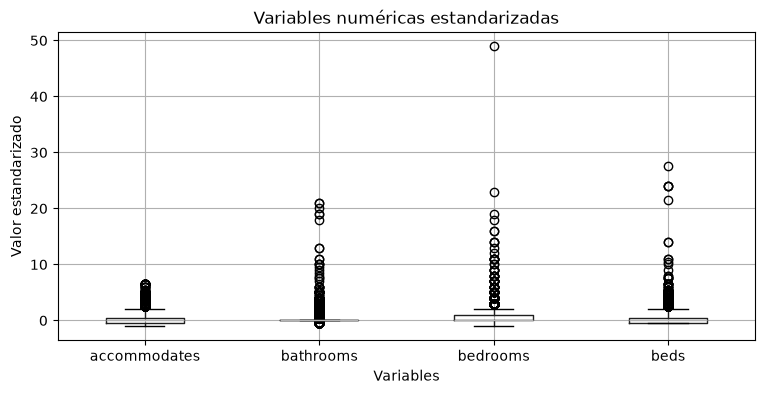

In [6]:
# Gráfico de control: variables explicativas estandarizadas
df_transformado.columns.tolist()
cols_num = ['accommodates', 'bathrooms', 'bedrooms', 'beds']
df_transformado[cols_num].boxplot(figsize=(9, 4))

plt.title("Variables numéricas estandarizadas")
plt.ylabel("Valor estandarizado")
plt.xlabel("Variables")
plt.show()

Interpretación del gráfico: El boxplot muestra que las variables estandarizadas se concentran principalmente alrededor de cero, lo que es consistente con el proceso de estandarización aplicado. Sin embargo, se observa una importante presencia de valores atípicos positivos, especialmente en las variables baños, dormitorios y camas. Destaca dormitorios, que presenta un valor extremadamente alejado del resto de las observaciones. Estos valores no deben considerarse automáticamente errores, ya que podrían corresponder a alojamientos reales con características poco frecuentes; sin embargo, resulta recomendable identificarlos y revisar su consistencia antes de utilizarlos en análisis posteriores.

### 4.1. Vinculación directa con la pregunta del informe

La POO (programacion orientada a objetos) organiza el procesamiento, pero el proyecto también debe mantener conexión con la problemática. Por eso usamos la copia `prep.df_analisis`, que conserva las categorías originales, para observar **cómo cambia el precio por comuna y tipo de habitación**. Se utiliza la **mediana** junto con el promedio porque el precio puede presentar valores extremos.

Este análisis es **descriptivo y exploratorio**: muestra diferencias y asociaciones observables, no causalidad.


In [7]:
# 4.1 Análisis del precio por comuna y tipo de habitación

base = df_analisis.copy()

# Definimos nombres de columnas según la estructura de df_analisis
col_comuna = "neighbourhood_cleansed" if "neighbourhood_cleansed" in base.columns else "comuna"
col_habitacion = "room_type" if "room_type" in base.columns else "tipo_habitacion"
col_precio = "price_quote_price_per_night" if "price_quote_price_per_night" in base.columns else "precio_por_noche"

# Análisis por comuna
por_comuna = (
    base.groupby(col_comuna)[col_precio]
    .agg(
        alojamientos="size",
        mediana="median",
        promedio="mean"
    )
    .sort_values("mediana")
    .head(10)
)

# Análisis por tipo de habitación
por_habitacion = (
    base.groupby(col_habitacion)[col_precio]
    .agg(
        alojamientos="size",
        mediana="median",
        promedio="mean"
    )
    .sort_values("mediana")
)

print("10 comunas con menor mediana de precio por noche:")
display(por_comuna.round(0))

print("\nPrecio por tipo de habitación:")
display(por_habitacion.round(0))

10 comunas con menor mediana de precio por noche:


,alojamientos,mediana,promedio
comuna,,,
Pedro Aguirre Cerda,5,25051.0,39829.0
Renca,33,29440.0,54003.0
Lo Prado,16,29882.0,43603.0
El Bosque,8,33882.0,41610.0
Quilicura,30,36614.0,53424.0
Cerro Navia,3,36992.0,43801.0
Quinta Normal,54,37227.0,38280.0
Estación Central,429,39941.0,46964.0
Maipú,87,40485.0,48321.0



Precio por tipo de habitación:


,alojamientos,mediana,promedio
tipo_habitacion,,,
Habitación compartida,59,20541.0,34104.0
Habitación privada,3148,34235.0,98419.0
Alojamiento completo,14424,64900.0,122687.0
Habitación de hotel,56,117138.0,162430.0


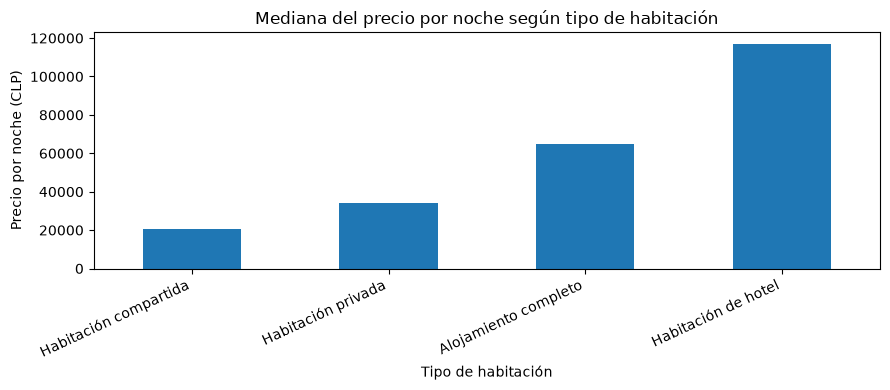

In [8]:
# Comparación visual de la mediana del precio por tipo de habitación

col_habitacion = "room_type" if "room_type" in df_analisis.columns else "tipo_habitacion"
col_precio = "price_quote_price_per_night" if "price_quote_price_per_night" in df_analisis.columns else "precio_por_noche"

mediana_habitacion = (
    df_analisis
    .groupby(col_habitacion)[col_precio]
    .median()
    .sort_values()
)

mediana_habitacion.plot(kind="bar", figsize=(9, 4))

plt.title("Mediana del precio por noche según tipo de habitación")
plt.xlabel("Tipo de habitación")
plt.ylabel("Precio por noche (CLP)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.show()


## 5. Herencia: reutilizar y especializar

La **herencia** permite crear una clase hija a partir de una clase base. En nuestro proyecto podemos comparar dos estrategias de tratamiento de nulos: eliminar filas o imputar la mediana. El ejemplo se mantiene pequeño para mostrar el concepto sin alterar el dataset principal.


In [9]:
class Limpiador:
    """Clase base: elimina filas que tengan algún nulo."""
    def limpiar(self, df):
        return df.dropna()


class LimpiadorPorMediana(Limpiador):
    """Clase hija: rellena nulos numéricos con la mediana."""
    def limpiar(self, df):
        df = df.copy()
        for columna in df.select_dtypes(include="number").columns:
            df[columna] = df[columna].fillna(df[columna].median())
        return df


# Ejemplo simple inspirado en variables del proyecto Airbnb
mini = pd.DataFrame({
    "precio": [35000.0, np.nan, 52000.0],
    "capacidad_personas": [1.0, 2.0, np.nan]
})
print("Tabla original:", mini.shape)
print("Limpiador base:", Limpiador().limpiar(mini).shape)
resultado_mediana = LimpiadorPorMediana().limpiar(mini)
print("LimpiadorPorMediana:", resultado_mediana.shape,
      "->", int(resultado_mediana.isna().sum().sum()), "nulos")
resultado_mediana



Tabla original: (3, 2)
Limpiador base: (1, 2)
LimpiadorPorMediana: (3, 2) -> 0 nulos


,precio,capacidad_personas
0,35000.0,1.0
1,43500.0,2.0
2,52000.0,1.5


**¿Para qué sirve esto en el proyecto?** Permite definir una estrategia común de limpieza y crear variantes sin reescribir todo el pipeline. En nuestra base real de Fase 2 no se detectaron nulos al cargarla, por lo que aquí la herencia se demuestra con una mini-tabla controlada.


## 6. Recursividad

Una función **recursiva** se llama a sí misma hasta alcanzar un caso base. Para conectarla con nuestro dataset, haremos un ejemplo muy simple: sumar tres precios de alojamientos seleccionados desde la base, sin usar `sum()`.


suma recursiva de precios por noche.

In [10]:
def suma_lista(numeros):
    """Suma recursivamente los elementos de una lista."""

    if len(numeros) == 0:       # Caso base
        return 0

    return numeros[0] + suma_lista(numeros[1:])


# Tomamos tres precios reales del dataset del proyecto
precios_ejemplo = (
   df_transformado["price_quote_price_per_night"]
    .head(3)
    .tolist()
)

print("Tres precios (CLP):", precios_ejemplo)
print("Suma recursiva (CLP):", suma_lista(precios_ejemplo))



Tres precios (CLP): [45647.0, 19856.0, 46776.0]
Suma recursiva (CLP): 112279.0


conteo recursivo de alojamientos adecuados para 1 o 2 personas.

In [11]:
# Ejemplo 2: contar recursivamente alojamientos para 1 o 2 personas

def contar_alojamientos_pequenos(capacidades):
    """Cuenta recursivamente alojamientos con capacidad de 1 o 2 personas."""
    
    # Caso base
    if len(capacidades) == 0:
        return 0
    
    # Si el alojamiento admite 1 o 2 personas, sumamos 1
    if capacidades[0] <= 2:
        return 1 + contar_alojamientos_pequenos(capacidades[1:])
    
    # Si admite más de 2 personas, no sumamos
    return contar_alojamientos_pequenos(capacidades[1:])


# Usamos df_analisis y la columna 'accommodates'
col_capacidad = "accommodates" if "accommodates" in df_analisis.columns else "capacidad_personas"

capacidades_ejemplo = (
    df_analisis[col_capacidad]
    .head(10)
    .tolist()
)

resultado = contar_alojamientos_pequenos(capacidades_ejemplo)

print("Capacidades analizadas:", capacidades_ejemplo)
print("Alojamientos para 1 o 2 personas:", resultado)

Capacidades analizadas: [2, 1, 3, 1, 3, 5, 2, 2, 2, 1]
Alojamientos para 1 o 2 personas: 7


La clave de toda recursión es tener **(1) un caso base** y **(2) un caso recursivo** que avance hacia él. En este ejemplo, la lista vacía es el caso base y cada llamada suma el primer precio con la suma del resto.


## 7. Eficiencia: bucle vs. operación vectorizada

Para que el ejemplo se relacione con Airbnb, compararemos dos formas de calcular el **precio total** de todos los alojamientos del dataset: un bucle de Python y la suma vectorizada de pandas/NumPy.


In [12]:
import timeit
import tracemalloc
import numpy as np
import pandas as pd

precios_total = df_analisis[col_precio].to_numpy()
REPETICIONES = 100

def con_bucle(valores):
    total = 0.0
    for precio in valores:
        total += precio
    return total

def vectorizado(valores):
    return float(valores.sum())

def medir(funcion, valores):
    # Tiempo: 100 ejecuciones sin seguimiento de memoria
    tiempo_total = timeit.timeit(
        lambda: funcion(valores),
        number=REPETICIONES
    )

    # Memoria: una ejecución independiente
    tracemalloc.start()
    try:
        funcion(valores)
        _, pico_bytes = tracemalloc.get_traced_memory()
    finally:
        tracemalloc.stop()

    return tiempo_total, pico_bytes

filas = []

for n in (1000, 5000, len(precios_total)):
    valores = precios_total[:n]

    # Verificar equivalencia antes de comparar rendimiento
    assert np.isclose(con_bucle(valores), vectorizado(valores))

    for nombre, funcion in (("Bucle", con_bucle), ("NumPy", vectorizado)):
        tiempo_total, pico_bytes = medir(funcion, valores)

        filas.append({
            "registros": n,
            "método": nombre,
            "tiempo_total_100_s": tiempo_total,
            "promedio_por_ejecucion_ms": tiempo_total / REPETICIONES * 1000,
            "pico_memoria_python_kib": pico_bytes / 1024,
        })

mediciones = pd.DataFrame(filas)
display(mediciones)

print(f"Suma de precios (CLP): ${vectorizado(precios_total):,.0f}")

,registros,método,tiempo_total_100_s,promedio_por_ejecucion_ms,pico_memoria_python_kib
0,1000,Bucle,0.009930,0.099300,0.28418
1,1000,NumPy,0.001502,0.015016,0.12500
2,5000,Bucle,0.038612,0.386122,0.28418
3,5000,NumPy,0.000216,0.002156,0.12500
4,17687,Bucle,0.128820,1.288202,0.28418
5,17687,NumPy,0.000569,0.005687,0.12500


Suma de precios (CLP): $2,090,563,484


In [13]:
import timeit
import tracemalloc
import numpy as np
import pandas as pd

precios_total = df_analisis[col_precio].to_numpy()
REPETICIONES = 100

def con_bucle(valores):
    total = 0.0
    for precio in valores:
        total += precio
    return total

def vectorizado(valores):
    return float(valores.sum())

def medir(funcion, valores):
    # Tiempo: 100 ejecuciones sin seguimiento de memoria
    tiempo_total = timeit.timeit(
        lambda: funcion(valores),
        number=REPETICIONES
    )

    # Memoria: una ejecución independiente
    tracemalloc.start()
    try:
        funcion(valores)
        _, pico_bytes = tracemalloc.get_traced_memory()
    finally:
        tracemalloc.stop()

    return tiempo_total, pico_bytes

filas = []

for n in (1000, 5000, len(precios_total)):
    valores = precios_total[:n]

    # Verificar equivalencia antes de comparar rendimiento
    assert np.isclose(con_bucle(valores), vectorizado(valores))

    for nombre, funcion in (("Bucle", con_bucle), ("NumPy", vectorizado)):
        tiempo_total, pico_bytes = medir(funcion, valores)

        filas.append({
            "registros": n,
            "método": nombre,
            "tiempo_total_100_s": tiempo_total,
            "promedio_por_ejecucion_ms": tiempo_total / REPETICIONES * 1000,
            "pico_memoria_python_kib": pico_bytes / 1024,
        })

mediciones = pd.DataFrame(filas)
display(mediciones)

print(f"Suma de precios (CLP): ${vectorizado(precios_total):,.0f}")

,registros,método,tiempo_total_100_s,promedio_por_ejecucion_ms,pico_memoria_python_kib
0,1000,Bucle,0.007721,0.077209,0.28418
1,1000,NumPy,0.000279,0.002785,0.12500
2,5000,Bucle,0.036095,0.360955,0.28418
3,5000,NumPy,0.005594,0.055944,0.12500
4,17687,Bucle,0.130854,1.308540,0.28418
5,17687,NumPy,0.001507,0.015070,0.12500


Suma de precios (CLP): $2,090,563,484


**Idea principal:** las operaciones vectorizadas de pandas/NumPy suelen ser más eficientes y expresivas que recorrer fila por fila. Medir ambos enfoques aporta evidencia sobre eficiencia, en lugar de asumirla.


## 8. Cómo queda aplicado  **nuestro proyecto Airbnb**



1. **Entrada:** `airbnb_procesado_lipieza(1).xls`, salida depurada de Fase 2 con categorías interpretables.
2. **POO:** `PreprocesadorAirbnb` encapsula carga, exploración, limpieza/validación, codificación, escalamiento y validación final.
3. **Variables categóricas:** `neighbourhood_cleansed`, `property_type` y `room_type` se transforman con One-Hot Encoding.
4. **Variables numéricas:** se estandarizan las variables explicativas; **el precio se mantiene en CLP** para conservar su interpretación.
5. **Pregunta del informe:** `df_analisis` permite comparar precio por comuna y tipo de habitación antes de perder las etiquetas categóricas.
6. **Conceptos F3:** se incluyen herencia, recursividad y comparación de eficiencia con ejemplos vinculados al dataset.
7. **Validación:** `prep.validar()` comprueba que la matriz transformada no tenga nulos ni texto sin codificar.





### 8.1. Exportación opcional del dataset transformado

La matriz transformada puede guardarse como salida de Fase 3. Esta exportación no reemplaza la copia interpretable usada para responder la pregunta del informe.


In [14]:
# Exportamos el dataset final transformado de la Fase 3
import os

SALIDA = "airbnb_f3_poo_transformado.csv"
RUTA_SALIDA = os.path.join("..", "..", "data", "processed", SALIDA)

# Si la carpeta no existe, la crea automáticamente
os.makedirs(os.path.dirname(RUTA_SALIDA), exist_ok=True)

# Exportamos df_transformado a CSV
df_transformado.to_csv(RUTA_SALIDA, index=False)

print(f"✓ Archivo exportado: {SALIDA}")
print(f"✓ Dimensiones finales: {df_transformado.shape}")

✓ Archivo exportado: airbnb_f3_poo_transformado.csv
✓ Dimensiones finales: (17687, 114)


## 9. Bibliografía (APA 7)

- Inside Airbnb. (2026). *Santiago, Región Metropolitana de Santiago: Detailed listings data (June 29, 2026)* [Data file].
- Salinas, O. (2026). *Estructura profesional de un proyecto Python* [Apunte]. Universidad Andrés Bello.
- Universidad Andrés Bello. (2026). *Guía de desarrollo — Evaluación Sumativa 1 (Fases 1 y 2)* [Documento de apoyo].
- The pandas development team. (2024). *pandas documentation*.
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.


